In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
# 1. Define a scaling range for N

node_sizes = np.arange(100, 10001, 200)
n_iter = 10

subcritical_sizes = []
critical_sizes = []
supercritical_sizes = []

print("Simulating scaling bounds...")
for n in node_sizes:
    sub_buffer = []
    critical_buffer = []
    super_buffer = []

    for _ in range(n_iter):
        # Subcritical: np = 0.5 (Should be O(log n))
        G_sub = nx.erdos_renyi_graph(n, p=0.5/n)
        if len(G_sub) > 0 and not nx.is_empty(G_sub):
            sub_buffer.append(len(max(nx.connected_components(G_sub), key=len)))
        else:
            sub_buffer.append(0)

        # Critical: np = 1.0 (Should be O(n^(2/3)))
        G_critical = nx.erdos_renyi_graph(n, p=1.0/n)
        critical_buffer.append(len(max(nx.connected_components(G_critical), key=len)))
            
        # Supercritical: np = 2.0 (Should be Theta(n))
        G_super = nx.erdos_renyi_graph(n, p=2.0/n)
        super_buffer.append(len(max(nx.connected_components(G_super), key=len)))
        
    subcritical_sizes.append(np.mean(sub_buffer))
    critical_sizes.append(np.mean(critical_buffer))
    supercritical_sizes.append(np.mean(super_buffer))



Simulating scaling bounds...


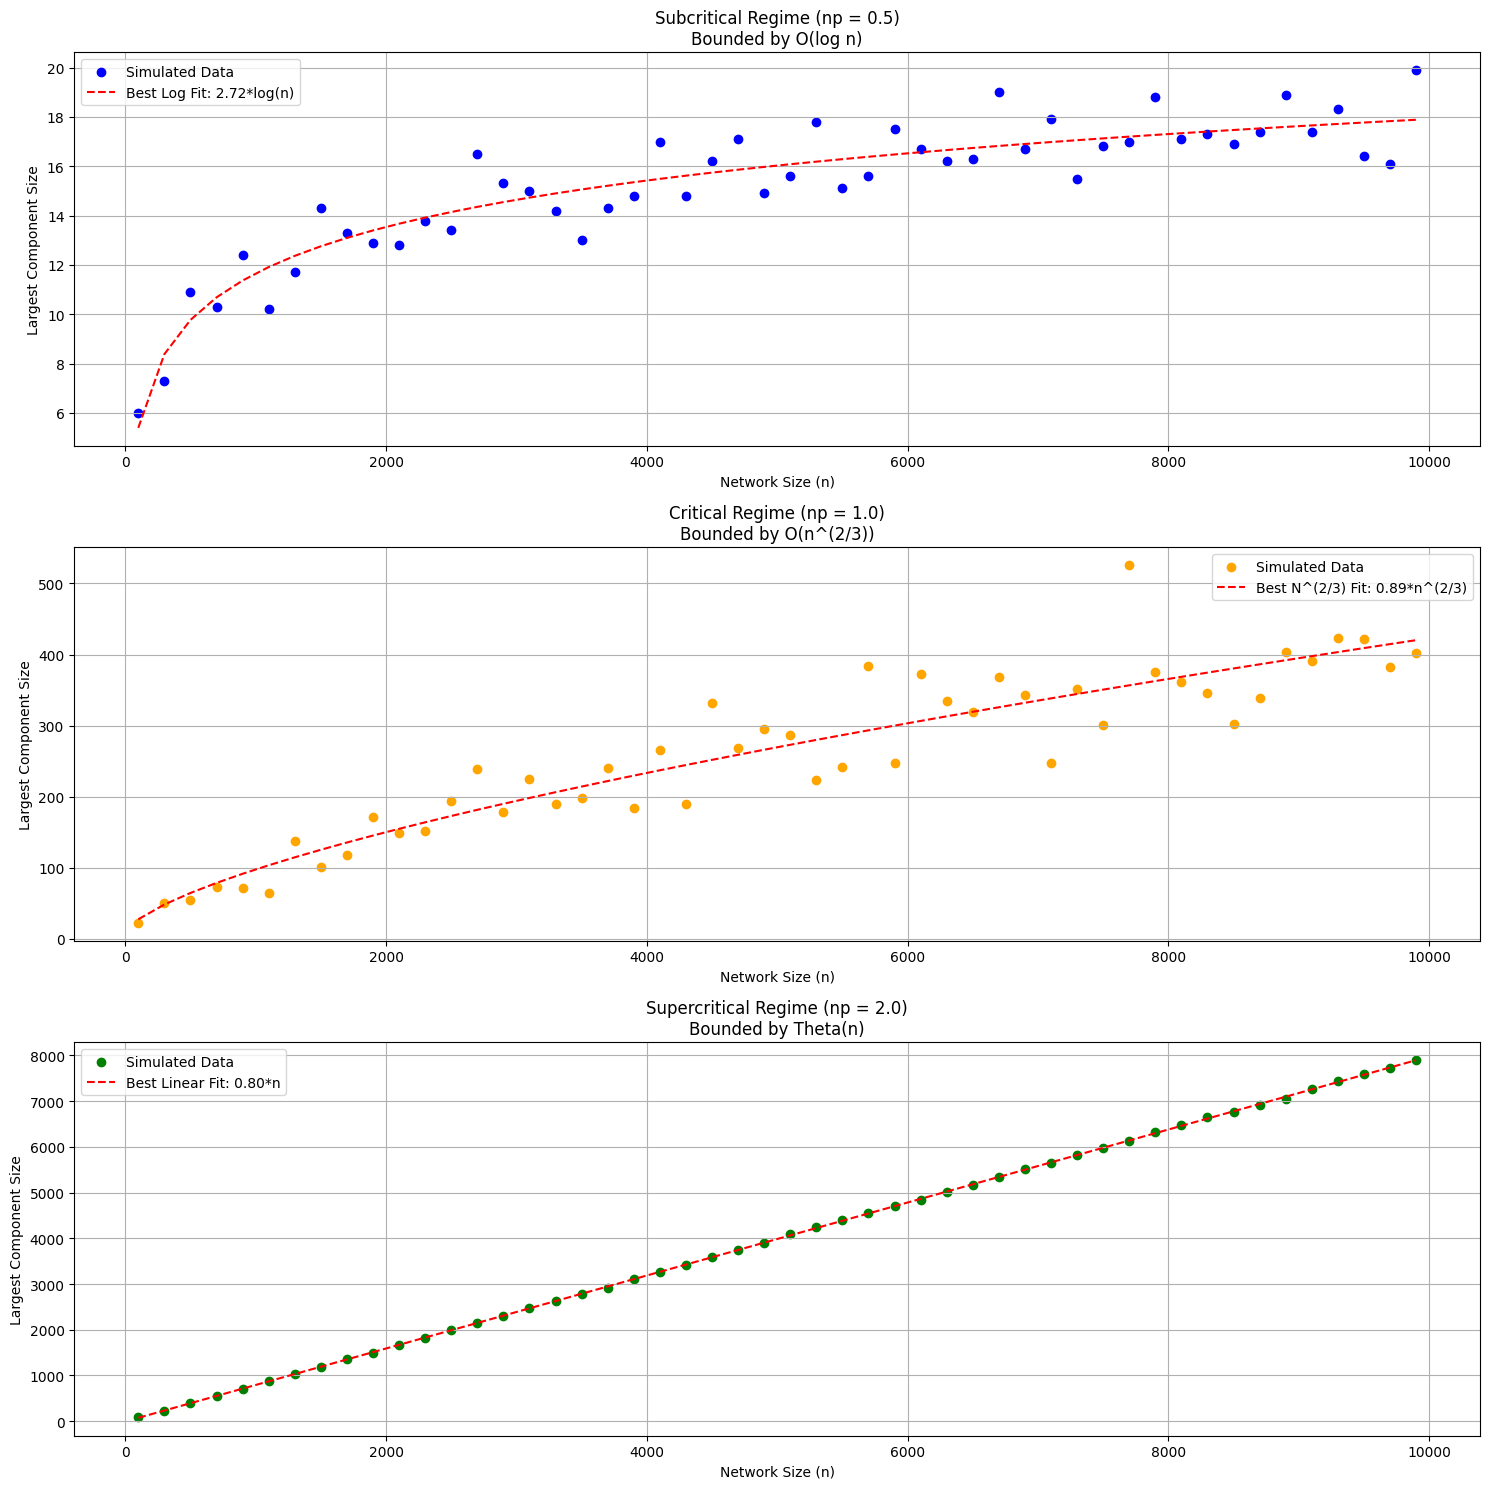

In [13]:
# --- 2. MATHEMATICAL PROOF (Curve Fitting) ---

# Ideal theoretical functions
def log_func(x, a, b): return a * np.log(x) + b

def n_pow_2_3_func(x, a, b): return a * np.power(x, 2/3) + b

def linear_func(x, a, b): return a * x + b

# Fit the simulated data to the expected math models
popt_sub, _ = curve_fit(log_func, node_sizes, subcritical_sizes)
popt_critical, _ = curve_fit(n_pow_2_3_func, node_sizes, critical_sizes)
popt_super, _ = curve_fit(linear_func, node_sizes, supercritical_sizes)

# --- 3. VISUALIZATION ---
plt.figure(figsize=(15, 15))

# Plot Subcritical Regime
plt.subplot(3, 1, 1)
plt.scatter(node_sizes, subcritical_sizes, color='blue', label='Simulated Data')
plt.plot(node_sizes, log_func(node_sizes, *popt_sub), 'r--', 
         label=f'Best Log Fit: {popt_sub[0]:.2f}*log(n)')
plt.title('Subcritical Regime (np = 0.5)\nBounded by O(log n)')
plt.xlabel('Network Size (n)')
plt.ylabel('Largest Component Size')
plt.grid(True)
plt.legend()

# Plot Critical Regime
plt.subplot(3, 1, 2)
plt.scatter(node_sizes, critical_sizes, color='orange', label='Simulated Data')
plt.plot(node_sizes, n_pow_2_3_func(node_sizes, *popt_critical), 'r--', 
         label=f'Best N^(2/3) Fit: {popt_critical[0]:.2f}*n^(2/3)')
plt.title('Critical Regime (np = 1.0)\nBounded by O(n^(2/3))')
plt.xlabel('Network Size (n)')
plt.ylabel('Largest Component Size')
plt.grid(True)
plt.legend()

# Plot Supercritical Regime
plt.subplot(3, 1, 3)
plt.scatter(node_sizes, supercritical_sizes, color='green', label='Simulated Data')
plt.plot(node_sizes, linear_func(node_sizes, *popt_super), 'r--', 
         label=f'Best Linear Fit: {popt_super[0]:.2f}*n')
plt.title('Supercritical Regime (np = 2.0)\nBounded by Theta(n)')
plt.xlabel('Network Size (n)')
plt.ylabel('Largest Component Size')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
df = pd.DataFrame({
    'Node Size': node_sizes,
    'Subcritical (np=0.5)': subcritical_sizes,
    'Critical (np=1.0)': critical_sizes,
    'Supercritical (np=2.0)': supercritical_sizes
})

df["Node Size"] = df["Node Size"].astype(int)
df[["Subcritical (np=0.5)", "Critical (np=1.0)", "Supercritical (np=2.0)"]] = df[["Subcritical (np=0.5)", "Critical (np=1.0)", "Supercritical (np=2.0)"]].astype(float)
df.to_parquet("giant_component_scaling_bounds.parquet", engine='fastparquet', index=False)
